Boukersi
Mariah
Grp1

Informatique–Génétique 2


TP -Simulation de la sélection génétique

PARTIE 1 –Sélection par l’antibiorésistance

Modéliser la croissance bactérienne

Modèle de Malthus

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Paramètres de la simulation
rmax = 0.2 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

In [5]:
# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

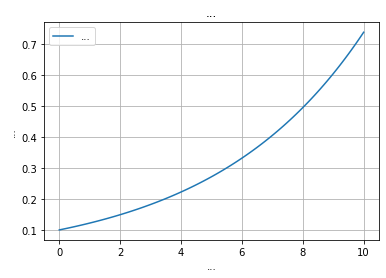

In [6]:
# Tracé du graphique
plt.title('...') # Titre du graphique
plt.plot(time, C, label='...') # Nom de la courbe
plt.xlabel('...') # Axe des X
plt.ylabel('...') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

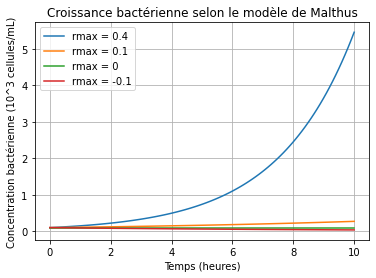

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax_values = [0.4, 0.1, 0, -0.1]
C0 = 0.1 # Concentration initiale
T = 10 # Durée totale de la simulation (heures)
dt = 0.1 # Pas de temps
N_steps = int(T / dt)

# Temps
time = np.linspace(0, T, N_steps)

# Boucle sur les différentes valeurs de rmax
for rmax in rmax_values:
    C = C0 * np.exp(rmax * time)
    plt.plot(time, C, label=f"rmax = {rmax}")

# Mise en forme du graphique
plt.title("Croissance bactérienne selon le modèle de Malthus")
plt.xlabel("Temps (heures)")
plt.ylabel("Concentration bactérienne (10^3 cellules/mL)")
plt.grid(True)
plt.legend()

# Affichage
plt.show()

Reponses:

1. Comment s’appelle ce type de courbe ?

Ce type de courbe est une courbe exponentielle. Elle représente une croissance exponentielle lorsque le taux de croissance rmax est positif.


2. En combien de temps la population double ?

Le temps de doublement se calcule avec la formule :

td = ln(2) / rmax

Pour rmax = 0,2 :

td = 0,693 / 0,2 ≈ 3,47 h

La population double donc en environ 3,5 heures.


3. Analyse des résultats

Les résultats obtenus sont cohérents avec le modèle de Malthus :

- Lorsque rmax = 0.4, la population bactérienne augmente très rapidement.
- Lorsque rmax = 0.1, la croissance est plus lente.
- Lorsque rmax = 0, la population reste constante au cours du temps.
- Lorsque rmax = -0.1, la population diminue progressivement.

On observe donc que plus la valeur de rmax est élevée, plus la croissance bactérienne est rapide.


4. Quelles sont les limites de ce modèle ?

Le modèle de Malthus présente plusieurs limites :

- il suppose une croissance infinie ;
- il ne prend pas en compte le manque de nutriments ;
- il ignore la limitation de l’espace ;
- il ne tient pas compte de la mortalité bactérienne ;
- il ne prend pas en compte l’accumulation de déchets.


5. Que faudrait-il ajouter pour le rendre plus réaliste ?

Pour rendre ce modèle plus réaliste, il faudrait :

- ajouter une capacité maximale du milieu ;
- prendre en compte la mortalité bactérienne ;
- modéliser la quantité de ressources disponibles ;

Cela permettrait d’obtenir un modèle plus proche de la réalité biologique.

Modèle de Monod


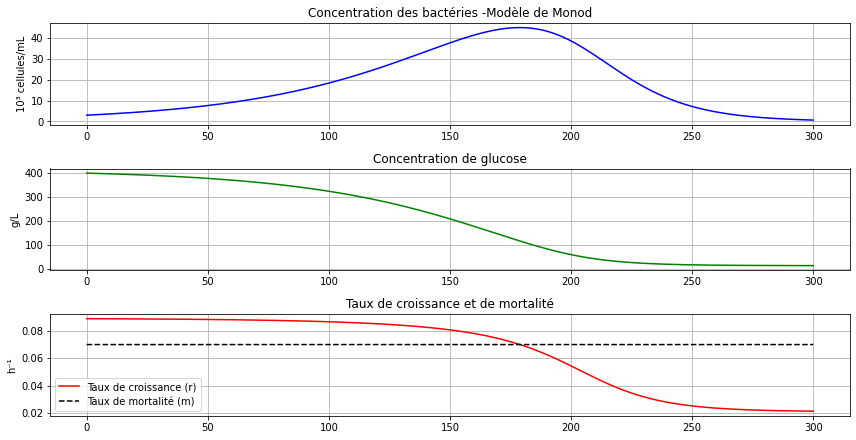

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 300 # Durée totale (heures)
dt = 0.1 # Pas de temps (heures)
N_steps = int(T / dt) # Nombre de pas de temps
# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10 # Taux de croissance maximal (h⁻¹)
K = 50 # Affinité pour le substrat (g/L)
m0 = 0.07 # Taux de mortalité minimal (h⁻¹)
C0 = 3 # Concentration initiale de bactéries (10³ cellules/mL)
# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
#======================
initial_glucose = 400 # Concentration initiale de glucose (g/L)
glucose_inflow = 0 # Flux entrant de glucose (g/L/h)
# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
#======================
initial_glucose = 400 # Concentration initiale de glucose (g/L)
glucose_inflow = 0 # Flux entrant de glucose (g/L/h)
# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps) # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)
# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0
# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])
    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r -m0) * C[i-1]
    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] -dt * r * C[i-1] + glucose_inflow * dt
    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0
# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)
# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))
# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries -Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)
# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)
# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--') 
# Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend() # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()


Reponse:

1. Décrivez l’évolution des différentes courbes.

La concentration bactérienne augmente d’abord progressivement grâce à la présence de glucose. Après avoir atteint un maximum, elle diminue lorsque le glucose devient insuffisant.

La concentration de glucose diminue continuellement au cours du temps car les bactéries le consomment pour leur croissance.

Le taux de croissance (r) diminue progressivement lorsque la quantité de glucose diminue.

Le taux de mortalité (m) reste constant au cours du temps.


2. Quel est le facteur limitant dans cette expérience ?

Le facteur limitant est le glucose. Lorsque sa concentration diminue fortement, les bactéries ne peuvent plus croître correctement et la population finit par décroître.


3. Pour quelles valeurs de r et m la population décroît ?

La population décroît lorsque le taux de mortalité m devient supérieur au taux de croissance r.

Autrement dit :
- si r > m : la population augmente ;
- si r = m : la population reste stable ;
- si r < m : la population diminue.

4. Faites varier les paramètres rmax, m0 et K.

- Une augmentation de rmax entraîne une croissance bactérienne plus rapide.
- Une augmentation de m0 entraîne une diminution plus rapide de la population bactérienne.
- Une augmentation de K permet aux bactéries de mieux utiliser le glucose même à faible concentration, ce qui prolonge la croissance.

5. Que faudrait-il pour que cette population se maintienne dans le temps ?

Pour maintenir la population bactérienne dans le temps, il faudrait :
- apporter continuellement du glucose ;
- maintenir un taux de croissance supérieur ou égal au taux de mortalité ;
- éviter l’épuisement des ressources ;
- éventuellement éliminer les déchets toxiques produits par les bactéries.

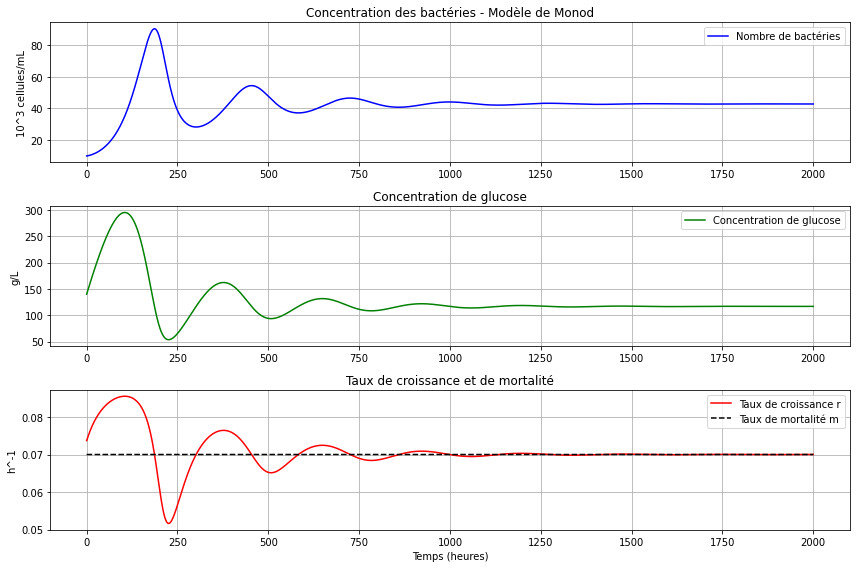

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMÈTRES DE LA SIMULATION
T = 2000
dt = 0.1
N_steps = int(T / dt)

# PARAMÈTRES DE LA SOUCHE
rmax = 0.10
K = 50
m0 = 0.07
C0 = 10

# PARAMÈTRES DU SUBSTRAT
initial_glucose = 140
glucose_inflow = 3

# INITIALISATION DES TABLEAUX
C = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# CONDITIONS INITIALES
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# SIMULATION
for i in range(1, N_steps):
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])
    m = m0
    
    C[i] = C[i-1] + dt * (r - m) * C[i-1]

    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt
    glucose_level[i] = max(glucose_level[i], 0)

    growth_rate[i] = r
    mortality_rate[i] = m

# AXE DES X EN HEURES
time = np.linspace(0, T, N_steps)

# TRACÉ DES COURBES
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(time, C, label="Nombre de bactéries", color="blue")
plt.title("Concentration des bactéries - Modèle de Monod")
plt.ylabel("10^3 cellules/mL")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time, glucose_level, label="Concentration de glucose", color="green")
plt.title("Concentration de glucose")
plt.ylabel("g/L")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time, growth_rate, label="Taux de croissance r", color="red")
plt.plot(time, mortality_rate, label="Taux de mortalité m", color="black", linestyle="--")
plt.title("Taux de croissance et de mortalité")
plt.xlabel("Temps (heures)")
plt.ylabel("h^-1")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



Reponse: 

1. Décrivez les courbes.

La concentration bactérienne augmente d’abord fortement car le glucose est disponible. Ensuite, elle présente des fluctuations : la population augmente puis diminue légèrement, avant de se stabiliser progressivement.

La concentration de glucose varie aussi au cours du temps. Elle est consommée par les bactéries, mais elle est aussi renouvelée grâce au flux entrant constant de glucose.

Le taux de croissance r dépend de la quantité de glucose disponible. Quand le glucose est abondant, r est élevé. Quand le glucose diminue, r diminue aussi. Le taux de mortalité m reste constant.

2. Pourquoi la population bactérienne présente des fluctuations marquées avant de se stabiliser ?

La population fluctue parce qu’il existe un décalage entre la consommation de glucose et la croissance bactérienne. Quand il y a beaucoup de glucose, les bactéries se multiplient rapidement. Elles consomment alors beaucoup de glucose, ce qui fait ensuite diminuer le taux de croissance. La mortalité devient alors plus importante que la croissance, donc la population diminue. Comme du glucose entre en continu dans le milieu, la croissance peut reprendre. Ces variations se répètent jusqu’à atteindre un équilibre.

3. Analyse des graphiques.

Les graphiques montrent que la population bactérienne dépend directement de la disponibilité du glucose. Le glucose est le facteur limitant de la croissance. Grâce au flux entrant de glucose, la population ne disparaît pas complètement et finit par se stabiliser. À l’équilibre, le taux de croissance r devient proche du taux de mortalité m.


Modéliser la sélection naturelle

Concurrence entre 2 souches


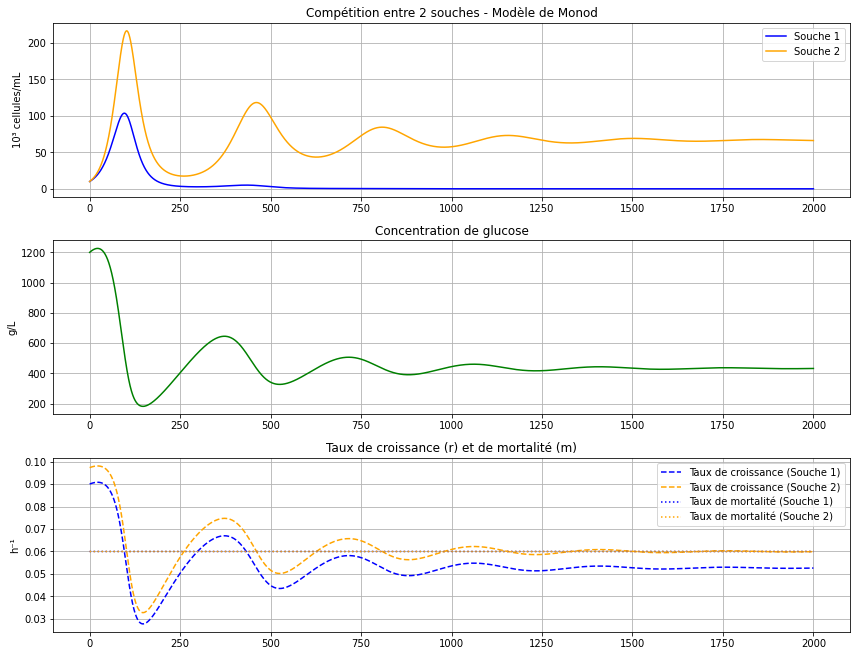

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================
# Paramètres pour la souche 1
# ====================================================

rmax_1 = 0.15 # Taux de croissance maximal (souche 1)
m0_1 = 0.06 # Taux de mortalité de base (souche 1)
K_1 = 800 # Constante de demi-saturation (souche 1)

# ====================================================
# Paramètres pour la souche 2
# ====================================================

rmax_2 = 0.15 # Taux de croissance maximal (souche 2)
m0_2 = 0.06 # Taux de mortalité de base (souche 2)
K_2 = 650 # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# ====================================================
# Paramètres du glucose
# ====================================================

initial_glucose = 1200 # Quantité initiale de glucose
glucose_inflow = 4 # Flux entrant de glucose (0 = système fermé)

# ====================================================
# Conditions initiales
# ====================================================

C0_1 = 10 # Concentration initiale de la souche 1
C0_2 = 10 # Concentration initiale de la souche 2

# ====================================================
# Paramètres de la simulation
# ====================================================

dt = 0.1 # Pas de temps
T = 2000 # Durée totale de la simulation
N_steps = int(T / dt) # Nombre de pas de temps

# ====================================================
# Initialisation des tableaux
# ====================================================

C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)

glucose_level = np.zeros(N_steps)

growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)

mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# ====================================================
# Conditions initiales
# ====================================================

C1[0] = C0_1
C2[0] = C0_2

glucose_level[0] = initial_glucose

growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])

mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# ====================================================
# Simulation
# ====================================================

for i in range(1, N_steps):

    # Calcul des taux de croissance pour chaque souche (modèle de Monod)

    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])

    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)

    # m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

    # m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

    # Mortalité constante

    m_1 = m0_1
    m_2 = m0_2

    # Mise à jour des populations bactériennes

    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]

    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)

    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])

    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux

    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2

    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# ====================================================
# Temps pour l'axe des abscisses
# ====================================================

time = np.linspace(0, T, N_steps)

# ====================================================
# Tracé des courbes
# ====================================================

plt.figure(figsize=(12, 12))

# Population des bactéries

plt.subplot(4, 1, 1)

plt.plot(time, C1, label='Souche 1', color='blue')

plt.plot(time, C2, label='Souche 2', color='orange')

plt.title('Compétition entre 2 souches - Modèle de Monod')

plt.ylabel('10³ cellules/mL')

plt.legend()

plt.grid(True)

# Niveau de glucose

plt.subplot(4, 1, 2)

plt.plot(time, glucose_level, label='Glucose', color='green')

plt.title('Concentration de glucose')

plt.ylabel('g/L')

plt.grid(True)

# Taux de croissance et mortalité

plt.subplot(4, 1, 3)

plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')

plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')

plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')

plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')

plt.title('Taux de croissance (r) et de mortalité (m)')

plt.ylabel('h⁻¹')

plt.legend()

plt.grid(True)

# Taux de mortalité

# plt.subplot(4, 1, 4)

# plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')

# plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')

# plt.title('Taux de mortalité (m)')

# plt.xlabel('Temps')

# plt.ylabel('Taux de mortalité (m)')

# plt.legend()

# plt.grid(True)

plt.tight_layout()

plt.show()

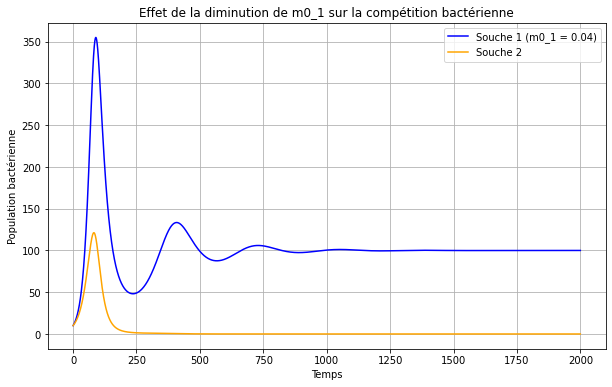

In [17]:
# ====================================================
# TEST : diminution de la mortalité de la souche 1
# ====================================================

m0_1 = 0.04 # Nouvelle valeur testée

# Réinitialisation des tableaux

C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)

glucose_level = np.zeros(N_steps)

growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)

mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales

C1[0] = C0_1
C2[0] = C0_2

glucose_level[0] = initial_glucose

# Simulation

for i in range(1, N_steps):

    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])

    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    m_1 = m0_1
    m_2 = m0_2

    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]

    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])

    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

# Temps

time = np.linspace(0, T, N_steps)

# Graphique comparatif

plt.figure(figsize=(10,6))

plt.plot(time, C1, label="Souche 1 (m0_1 = 0.04)", color="blue")

plt.plot(time, C2, label="Souche 2", color="orange")

plt.title("Effet de la diminution de m0_1 sur la compétition bactérienne")

plt.xlabel("Temps")

plt.ylabel("Population bactérienne")

plt.legend()

plt.grid(True)

plt.show()



Reponse:

1. Décrivez les courbes.

Les deux populations bactériennes augmentent rapidement au début grâce à la grande quantité de glucose disponible. Ensuite, les populations présentent des oscillations avant de tendre vers une stabilisation.

La souche 2 devient progressivement dominante par rapport à la souche 1. Sa population reste plus élevée à long terme.

La concentration de glucose diminue fortement au début à cause de la consommation des deux souches, puis elle oscille avant de se stabiliser grâce à l’apport continu de glucose.

Les taux de croissance diminuent progressivement et se rapprochent des taux de mortalité lorsque le système atteint un équilibre.


2. Quel est le résultat de la concurrence sur le devenir des populations ?

La concurrence entraîne un avantage pour la souche 2. Cette souche possède une meilleure affinité pour le glucose grâce à une valeur de K plus faible (K2 = 650 contre K1 = 800).

Elle utilise donc plus efficacement le glucose lorsque celui-ci devient limité. La souche 2 devient dominante tandis que la souche 1 reste présente mais en plus faible quantité.


3. Modifiez le paramètre m de la souche 1. À partir de quelle valeur celle-ci l’emporte sur la souche 2 ?

Lorsque le taux de mortalité de la souche 1 diminue suffisamment, elle peut devenir plus compétitive que la souche 2.

En diminuant progressivement m0_1, on observe que la souche 1 commence à dominer lorsque m0_1 devient inférieur à environ 0,05.

À partir de cette valeur, la croissance de la souche 1 compense davantage les pertes dues à la mortalité et elle peut dépasser la souche 2.


4. Analyse des graphiques.

Les graphiques montrent une compétition entre deux populations partageant une même ressource limitée : le glucose.

La disponibilité du glucose contrôle directement les taux de croissance des deux souches. Les oscillations observées traduisent l’ajustement progressif du système entre consommation du glucose et croissance bactérienne.

Le système finit par atteindre un équilibre dynamique où les populations et le glucose deviennent relativement stables.



Sélection par les antibiotiques

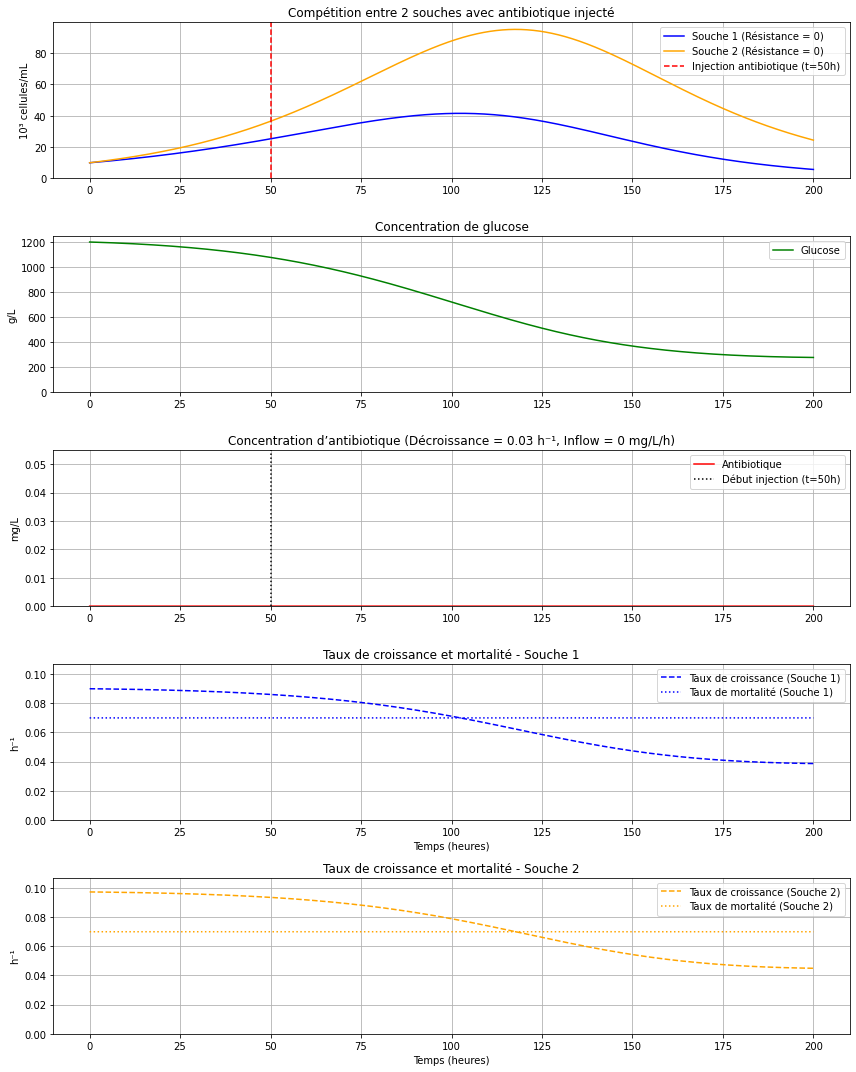

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================
# PARAMÈTRES POUR LES SOUCHES
# ====================================================

# Souche 1
rmax_1 = 0.15 # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07 # Taux de mortalité de base (h⁻¹)
K_1 = 800 # Constante de demi-saturation (g/L)
resistance_1 = 0 # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15 # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07 # Taux de mortalité de base (h⁻¹)
K_2 = 650 # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# ====================================================
# PARAMÈTRES DU GLUCOSE
# ====================================================

initial_glucose = 1200 # Concentration initiale de glucose (g/L)
glucose_inflow = 1 # Flux entrant de glucose (g/L/h)

# ====================================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# ====================================================

initial_antibiotic = 0 # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03 # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0 # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50 # Temps (en heures) avant l'injection

# ====================================================
# CONDITIONS INITIALES
# ====================================================

C0_1 = 10 # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10 # Concentration initiale de la souche 2 (10³ cellules/mL)

# ====================================================
# PARAMÈTRES DE LA SIMULATION
# ====================================================

dt = 0.1 # Pas de temps (h)

T = 200 # Durée totale (h)

N_steps = int(T / dt)

# ====================================================
# INITIALISATION DES TABLEAUX
# ====================================================

C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)

glucose_level = np.zeros(N_steps)

antibiotic_level = np.zeros(N_steps)

growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)

mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales

C1[0] = C0_1
C2[0] = C0_2

glucose_level[0] = initial_glucose
antibiotic_level[0] = 0

growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])

growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])

mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# ====================================================
# SIMULATION
# ====================================================

for i in range(1, N_steps):

    current_time = i * dt

    # Calcul des taux de croissance

    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])

    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)

    if current_time < antibiotic_start_time:

        antibiotic_level[i] = 0

    else:

        if antibiotic_level[i-1] == 0: # Premier pas après l’injection

            antibiotic_level[i] = initial_antibiotic

        else:

            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité

    if antibiotic_level[i] > 0:

        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)

        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)

    else:

        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

        m_1 = m0_1 * (1 + antibiotic_effect_1)

        m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations

    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]

    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose

    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])

    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux

    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2

    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# ====================================================
# TEMPS POUR L’AXE DES ABSCISSES
# ====================================================

time = np.linspace(0, T, N_steps)

# ====================================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# ====================================================

max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))

max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))

y_max_rates = max(max_growth, max_mortality) * 1.1

# ====================================================
# TRACÉ DES COURBES
# ====================================================

plt.figure(figsize=(12, 15))

# 1. Populations bactériennes

plt.subplot(5, 1, 1)

plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')

plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')

plt.axvline(x=antibiotic_start_time, color='red', linestyle='--',
label=f'Injection antibiotique (t={antibiotic_start_time}h)')

plt.title('Compétition entre 2 souches avec antibiotique injecté')

plt.ylabel('10³ cellules/mL')

plt.legend()

plt.grid(True)

plt.ylim(bottom=0)

# 2. Concentration de glucose

plt.subplot(5, 1, 2)

plt.plot(time, glucose_level, label='Glucose', color='green')

plt.title('Concentration de glucose')

plt.ylabel('g/L')

plt.legend()

plt.grid(True)

plt.ylim(bottom=0)

# 3. Concentration d’antibiotique

plt.subplot(5, 1, 3)

plt.plot(time, antibiotic_level, label='Antibiotique', color='red')

plt.axvline(x=antibiotic_start_time, color='black', linestyle=':',
label=f'Début injection (t={antibiotic_start_time}h)')

plt.title(f'Concentration d’antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')

plt.ylabel('mg/L')

plt.legend()

plt.grid(True)

plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)

plt.subplot(5, 1, 4)

plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')

plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')

plt.title('Taux de croissance et mortalité - Souche 1')

plt.xlabel('Temps (heures)')

plt.ylabel('h⁻¹')

plt.legend()

plt.grid(True)

plt.ylim(bottom=0, top=y_max_rates)

# 5. Taux de croissance et mortalité (Souche 2)

plt.subplot(5, 1, 5)

plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')

plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')

plt.title('Taux de croissance et mortalité - Souche 2')

plt.xlabel('Temps (heures)')

plt.ylabel('h⁻¹')

plt.legend()

plt.grid(True)

plt.ylim(bottom=0, top=y_max_rates)

plt.tight_layout()

plt.show()

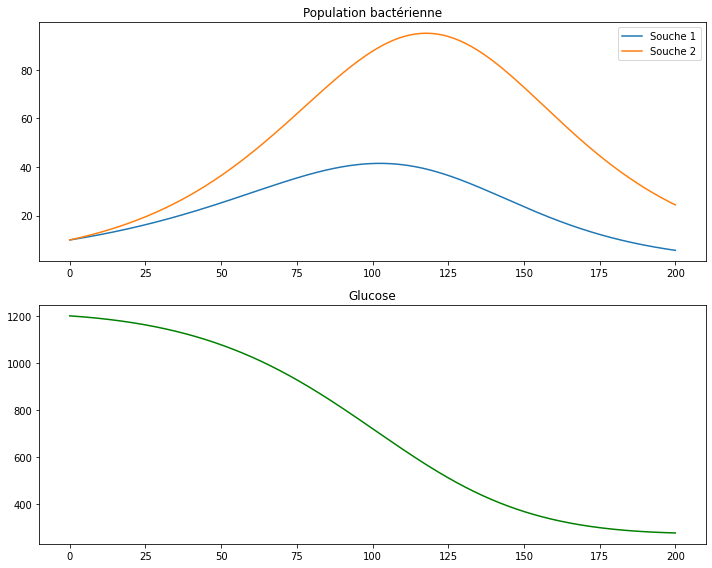

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMÈTRES DES SOUCHES
rmax_1 = 0.15
m0_1 = 0.07
K_1 = 800
resistance_1 = 0

rmax_2 = 0.15
m0_2 = 0.07
K_2 = 650
resistance_2 = 0

# GLUCOSE
initial_glucose = 1200
glucose_inflow = 1

# ANTIBIOTIQUE
initial_antibiotic = 0
antibiotic_intensity = 3
antibiotic_decay = 0.03
antibiotic_inflow = 0
antibiotic_start_time = 50

# CONDITIONS INITIALES
C0_1 = 10
C0_2 = 10

# SIMULATION
dt = 0.1
T = 200
N_steps = int(T/dt)

# TABLEAUX
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)

# CONDITIONS INITIALES
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose

# BOUCLE
for i in range(1, N_steps):

    r1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    m1 = m0_1
    m2 = m0_2

    C1[i] = C1[i-1] + dt * (r1 - m1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r2 - m2) * C2[i-1]

    consommation = r1*C1[i-1] + r2*C2[i-1]

    glucose_level[i] = glucose_level[i-1] - dt*consommation + glucose_inflow*dt

time = np.linspace(0, T, N_steps)

plt.figure(figsize=(10,8))

plt.subplot(2,1,1)
plt.plot(time, C1, label="Souche 1")
plt.plot(time, C2, label="Souche 2")
plt.legend()
plt.title("Population bactérienne")

plt.subplot(2,1,2)
plt.plot(time, glucose_level, color="green")
plt.title("Glucose")

plt.tight_layout()
plt.show()

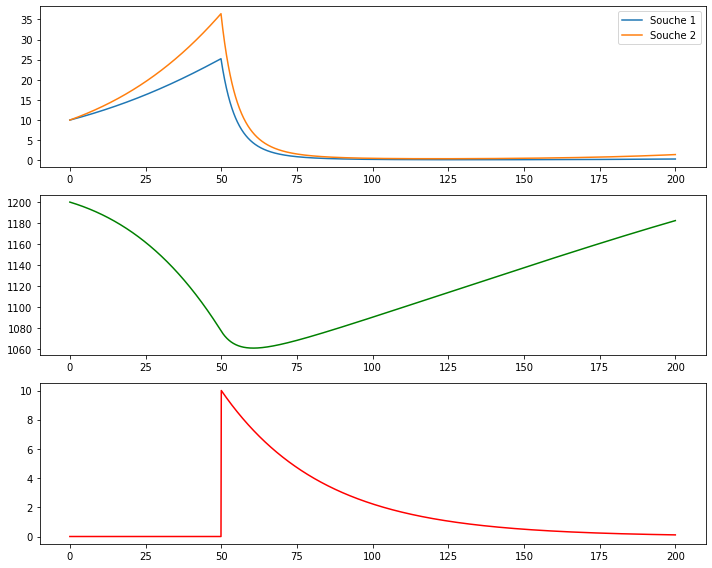

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMÈTRES DES SOUCHES
rmax_1 = 0.15
m0_1 = 0.07
K_1 = 800
resistance_1 = 0

rmax_2 = 0.15
m0_2 = 0.07
K_2 = 650
resistance_2 = 0

# GLUCOSE
initial_glucose = 1200
glucose_inflow = 1

# ANTIBIOTIQUE
initial_antibiotic = 10
antibiotic_intensity = 3
antibiotic_decay = 0.03
antibiotic_inflow = 0
antibiotic_start_time = 50

# CONDITIONS INITIALES
C0_1 = 10
C0_2 = 10

# SIMULATION
dt = 0.1
T = 200
N_steps = int(T/dt)

# TABLEAUX
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)

C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose

for i in range(1, N_steps):

    current_time = i * dt

    r1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay*dt)

    effet1 = antibiotic_intensity * (antibiotic_level[i]/initial_antibiotic)
    effet2 = antibiotic_intensity * (antibiotic_level[i]/initial_antibiotic)

    m1 = m0_1 * (1 + effet1)
    m2 = m0_2 * (1 + effet2)

    C1[i] = C1[i-1] + dt*(r1-m1)*C1[i-1]
    C2[i] = C2[i-1] + dt*(r2-m2)*C2[i-1]

    consommation = r1*C1[i-1] + r2*C2[i-1]

    glucose_level[i] = glucose_level[i-1] - dt*consommation + glucose_inflow*dt

time = np.linspace(0, T, N_steps)

plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(time, C1, label="Souche 1")
plt.plot(time, C2, label="Souche 2")
plt.legend()

plt.subplot(3,1,2)
plt.plot(time, glucose_level, color="green")

plt.subplot(3,1,3)
plt.plot(time, antibiotic_level, color="red")

plt.tight_layout()
plt.show()

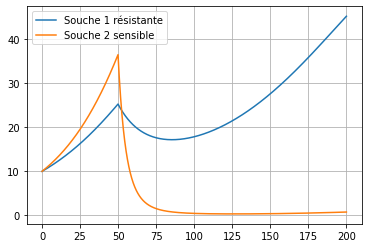

In [23]:
import numpy as np
import matplotlib.pyplot as plt

rmax_1 = 0.15
m0_1 = 0.07
K_1 = 800
resistance_1 = 0.8

rmax_2 = 0.15
m0_2 = 0.07
K_2 = 650
resistance_2 = 0

initial_glucose = 1200
glucose_inflow = 1

initial_antibiotic = 10
antibiotic_intensity = 3
antibiotic_decay = 0.03
antibiotic_inflow = 0
antibiotic_start_time = 50

C0_1 = 10
C0_2 = 10

dt = 0.1
T = 200
N_steps = int(T/dt)

C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)

C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose

for i in range(1, N_steps):

    current_time = i*dt

    r1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1]*(1-antibiotic_decay*dt)

    effet1 = antibiotic_intensity * (antibiotic_level[i]/initial_antibiotic) * (1-resistance_1)
    effet2 = antibiotic_intensity * (antibiotic_level[i]/initial_antibiotic) * (1-resistance_2)

    m1 = m0_1 * (1+effet1)
    m2 = m0_2 * (1+effet2)

    C1[i] = C1[i-1] + dt*(r1-m1)*C1[i-1]
    C2[i] = C2[i-1] + dt*(r2-m2)*C2[i-1]

    consommation = r1*C1[i-1] + r2*C2[i-1]

    glucose_level[i] = glucose_level[i-1] - dt*consommation + glucose_inflow*dt

time = np.linspace(0,T,N_steps)

plt.plot(time,C1,label="Souche 1 résistante")
plt.plot(time,C2,label="Souche 2 sensible")
plt.legend()
plt.grid()
plt.show()

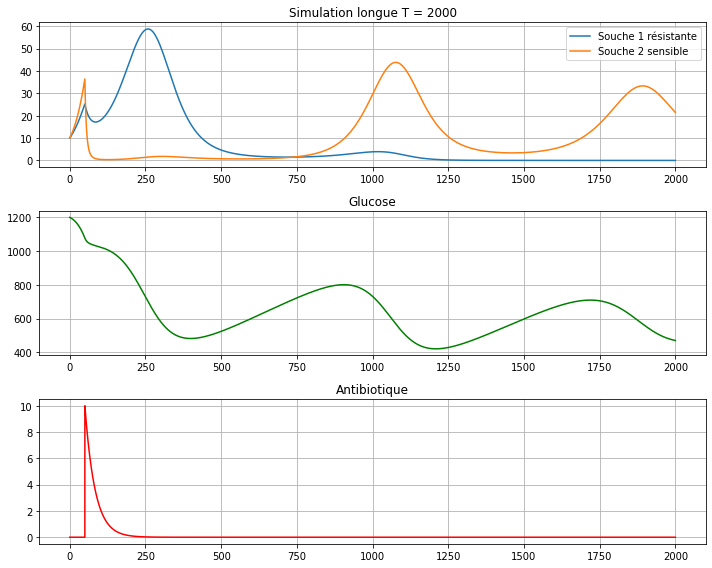

In [24]:
. Avec initial_antibiotic = 10

Lorsqu’on ajoute un antibiotique, la mortalité des bactéries augmente après l’injection. Les populations diminuent donc fortement. Comme les deux souches ne sont pas résistantes, elles sont toutes les deux affectées par l’antibiotique.

2. Avec resistance_1 = 0.8

Lorsque la souche 1 est résistante à l’antibiotique, elle est moins touchée par l’augmentation de mortalité. La souche 2, qui n’est pas résistante, diminue davantage. La souche 1 est donc favorisée par la présence de l’antibiotique.

3. Avec T = 2000

En augmentant la durée de la simulation, on observe mieux l’évolution à long terme. La souche résistante se maintient mieux dans le temps que la souche sensible. Le système peut finir par se stabiliser autour d’un équilibre.

4. Avec antibiotic_inflow = 0.05

Lorsqu’il existe un apport continu d’antibiotique, la pression de sélection reste présente dans le milieu. Les bactéries sensibles sont désavantagées, tandis que les bactéries résistantes sont favorisées.

5. Conclusion

La pollution résiduelle d’antibiotique favorise l’émergence et le maintien des souches résistantes. Même une faible quantité d’antibiotique dans l’environnement peut sélectionner les bactéries les plus résistantes, car elles survivent mieux que les souches sensibles.


import numpy as np
import matplotlib.pyplot as plt

rmax_1 = 0.15
m0_1 = 0.07
K_1 = 800
resistance_1 = 0.8

rmax_2 = 0.15
m0_2 = 0.07
K_2 = 650
resistance_2 = 0

initial_glucose = 1200
glucose_inflow = 1

initial_antibiotic = 10
antibiotic_intensity = 3
antibiotic_decay = 0.03
antibiotic_inflow = 0
antibiotic_start_time = 50

C0_1 = 10
C0_2 = 10

dt = 0.1
T = 2000
N_steps = int(T / dt)

C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)

C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose

for i in range(1, N_steps):
    current_time = i * dt

    r1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt)

    effet1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
    effet2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)

    m1 = m0_1 * (1 + effet1)
    m2 = m0_2 * (1 + effet2)

    C1[i] = C1[i-1] + dt * (r1 - m1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r2 - m2) * C2[i-1]

    consommation = r1 * C1[i-1] + r2 * C2[i-1]
    glucose_level[i] = glucose_level[i-1] - dt * consommation + glucose_inflow * dt

time = np.linspace(0, T, N_steps)

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(time, C1, label="Souche 1 résistante")
plt.plot(time, C2, label="Souche 2 sensible")
plt.title("Simulation longue T = 2000")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(time, glucose_level, color="green")
plt.title("Glucose")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(time, antibiotic_level, color="red")
plt.title("Antibiotique")
plt.grid(True)

plt.tight_layout()
plt.show()

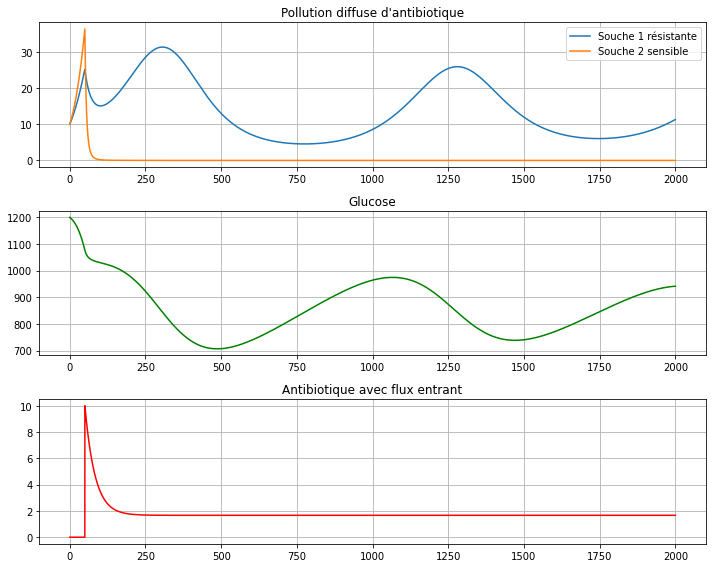

In [25]:

import numpy as np
import matplotlib.pyplot as plt

rmax_1 = 0.15
m0_1 = 0.07
K_1 = 800
resistance_1 = 0.8

rmax_2 = 0.15
m0_2 = 0.07
K_2 = 650
resistance_2 = 0

initial_glucose = 1200
glucose_inflow = 1

initial_antibiotic = 10
antibiotic_intensity = 3
antibiotic_decay = 0.03
antibiotic_inflow = 0.05
antibiotic_start_time = 50

C0_1 = 10
C0_2 = 10

dt = 0.1
T = 2000
N_steps = int(T / dt)

C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)

C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose

for i in range(1, N_steps):
    current_time = i * dt

    r1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    effet1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
    effet2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)

    m1 = m0_1 * (1 + effet1)
    m2 = m0_2 * (1 + effet2)

    C1[i] = C1[i-1] + dt * (r1 - m1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r2 - m2) * C2[i-1]

    consommation = r1 * C1[i-1] + r2 * C2[i-1]
    glucose_level[i] = glucose_level[i-1] - dt * consommation + glucose_inflow * dt

time = np.linspace(0, T, N_steps)

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(time, C1, label="Souche 1 résistante")
plt.plot(time, C2, label="Souche 2 sensible")
plt.title("Pollution diffuse d'antibiotique")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(time, glucose_level, color="green")
plt.title("Glucose")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(time, antibiotic_level, color="red")
plt.title("Antibiotique avec flux entrant")
plt.grid(True)

plt.tight_layout()
plt.show()

Reponses:
1. Avec initial_antibiotic = 10

Lorsqu’on ajoute un antibiotique, la mortalité des bactéries augmente après l’injection. Les populations diminuent donc fortement. Comme les deux souches ne sont pas résistantes, elles sont toutes les deux affectées par l’antibiotique.

2. Avec resistance_1 = 0.8

Lorsque la souche 1 est résistante à l’antibiotique, elle est moins touchée par l’augmentation de mortalité. La souche 2, qui n’est pas résistante, diminue davantage. La souche 1 est donc favorisée par la présence de l’antibiotique.

3. Avec T = 2000

En augmentant la durée de la simulation, on observe mieux l’évolution à long terme. La souche résistante se maintient mieux dans le temps que la souche sensible. Le système peut finir par se stabiliser autour d’un équilibre.

4. Avec antibiotic_inflow = 0.05

Lorsqu’il existe un apport continu d’antibiotique, la pression de sélection reste présente dans le milieu. Les bactéries sensibles sont désavantagées, tandis que les bactéries résistantes sont favorisées.

5. Conclusion

La pollution résiduelle d’antibiotique favorise l’émergence et le maintien des souches résistantes. Même une faible quantité d’antibiotique dans l’environnement peut sélectionner les bactéries les plus résistantes, car elles survivent mieux que les souches sensibles.


